In [1]:
import os
import os, sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Sequential
import torch.optim as optim
import voxelmorph as vxm
import neurite as ne
import scipy.ndimage

os.environ['VXM_BACKEND'] = 'pytorch'

backend:pytorch
Pytorch


In [2]:
os.environ.get('VXM_BACKEND')

'pytorch'

In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [4]:
# 画像を読み込み
x_train = np.load('CT_Train_NoBed.npz')['Train']
x_train = np.transpose(x_train, (3, 0, 1, 2))

# 新しいボリュームのサイズ (各軸を半分にする)
new_shape = tuple([dim // 2 for dim in x_train.shape[1:]])

# サイズを半分に縮小
x_train_resized = np.zeros((x_train.shape[0], *new_shape))  # 新しい形に合わせて初期化

for i in range(x_train.shape[0]):
    # 各画像を縮小
    x_train_resized[i] = scipy.ndimage.zoom(x_train[i], (0.5, 0.5, 0.5), order=3)
print('Resized train vol_shape:', x_train_resized.shape[1:])
print('Resized train shape:', x_train_resized.shape)
x_train = x_train_resized

Resized train vol_shape: (64, 128, 128)
Resized train shape: (400, 64, 128, 128)


In [5]:
import torch

def vxm_data_generator(x_data, batch_size):
    vol_shape = x_data.shape[1:]  # データ形状を取得
    ndims = len(vol_shape)
    
    zero_phi = np.zeros([batch_size, *vol_shape, ndims])
    
    while True:
        idx1 = np.random.randint(0, x_data.shape[0], size=batch_size)
        moving_images = x_data[idx1, ..., np.newaxis]
        idx2 = np.random.randint(0, x_data.shape[0], size=batch_size)
        fixed_images = x_data[idx2, ..., np.newaxis]

        # TensorFlowからPyTorchのデータ形式に変換
        moving_images = torch.tensor(moving_images).permute(0, 4, 1, 2, 3).float()
        fixed_images = torch.tensor(fixed_images).permute(0, 4, 1, 2, 3).float()

        # チャンネルを最初の次元に追加
        moving_images = moving_images.permute(0, 1, 2, 3, 4)  # チャンネルを最初の次元に移動
        fixed_images = fixed_images.permute(0, 1, 2, 3, 4)  # チャンネルを最初の次元に移動

        inputs = [moving_images, fixed_images]
        outputs = [fixed_images, zero_phi]

        yield (inputs, outputs)

In [6]:
train_generator = vxm_data_generator(x_train, batch_size=2)
in_sample, out_sample = next(train_generator)

# in_sampleとout_sampleの内容を確認する
print("Input Sample Shapes:")
print("Moving Images Shape:", in_sample[0].shape)
print("Fixed Images Shape:", in_sample[1].shape)

print("\nOutput Sample Shapes:")
print("Moved Images (Fixed) Shape:", out_sample[0].shape)
print("Zero Gradient Shape:", out_sample[1].shape)

Input Sample Shapes:
Moving Images Shape: torch.Size([2, 1, 64, 128, 128])
Fixed Images Shape: torch.Size([2, 1, 64, 128, 128])

Output Sample Shapes:
Moved Images (Fixed) Shape: torch.Size([2, 1, 64, 128, 128])
Zero Gradient Shape: (2, 64, 128, 128, 3)


In [7]:
mse_loss = vxm.losses.MSE().loss
grad_loss = vxm.losses.Grad('l2').loss

def total_loss(y_true, y_pred):
    mse = mse_loss(y_true, y_pred)
    grad = grad_loss(y_true, y_pred)
    return mse + 0.01 * grad, mse, grad
#     return mse_loss(y_true, y_pred)

def MSE_Loss(y_true, y_pred):
    mse = mse_loss(y_true, y_pred)
    return mse

def lncc_loss(I, J, window=9, eps=1e-5):
    # I, J: (B, 1, D, H, W)
    padding = window // 2
    weight = torch.ones(1, 1, window, window, window, device=I.device)

    I2 = I * I
    J2 = J * J
    IJ = I * J

    I_sum = F.conv3d(I, weight, padding=padding)
    J_sum = F.conv3d(J, weight, padding=padding)
    I2_sum = F.conv3d(I2, weight, padding=padding)
    J2_sum = F.conv3d(J2, weight, padding=padding)
    IJ_sum = F.conv3d(IJ, weight, padding=padding)

    win_size = window ** 3
    u_I = I_sum / win_size
    u_J = J_sum / win_size

    cross = IJ_sum - u_J * I_sum - u_I * J_sum + u_I * u_J * win_size
    I_var = I2_sum - 2 * u_I * I_sum + u_I * u_I * win_size
    J_var = J2_sum - 2 * u_J * J_sum + u_J * u_J * win_size

    lncc = cross * cross / (I_var * J_var + eps)
    return -torch.mean(lncc)  # maximize LNCC → minimize -LNCC

In [8]:
# configure unet input shape (concatenation of moving and fixed images)
ndim = 3
unet_input_features = 2
# inshape = (*x_train.shape[1:], unet_input_features)

nb_features = [
    [32, 64, 64, 64, 64],
    [64, 64, 64, 64, 64, 32, 16, 16]
]

In [9]:
model3D = vxm.networks.VxmDense1((64, 128, 128), nb_features, int_steps=0)
model3D.to(device)
optimizer = optim.Adam(model3D.parameters(), lr=1e-4)

5
6
7
6
7
6
7
6
7
6
7
64
128
8
9
64
10
8
9
64
10
8
9
64
10
8
9
64
10
8
9
64
10
11
11
11
[32, 64, 64]


C:\Users\user\anaconda3\envs\nn\lib\site-packages\torch\functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\TensorShape.cpp:3550.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


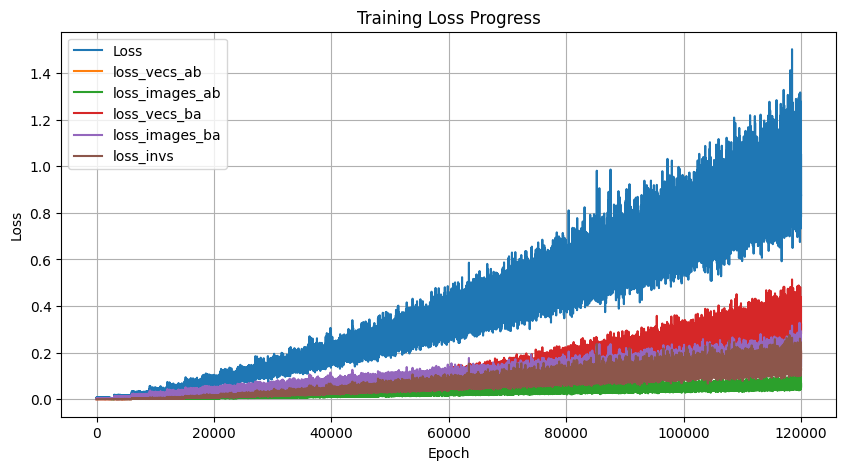

Epoch 119991/120000, Loss: 0.8769, loss_vec_ab: 0.2004, loss_image_ab: 0.0581, loss_vec_ba: 0.3205, loss_image_ba: 0.1699, loss_inv: 0.1280, Shift Range: ±40 pixels
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 119992/120000, Loss: 1.0043, loss_vec_ab: 0.2142, loss_image_ab: 0.0637, loss_vec_ba: 0.3709, loss_image_ba: 0.1996, loss_inv: 0.1560, Shift Range: ±40 pixels
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 119993/120000, Loss: 1.0050, loss_vec_ab: 0.2275, loss_image_ab: 0.0629, loss_vec_ba: 0.3708, loss_image_ba: 0.1946, loss_inv: 0.1493, Shift Range: ±40 pixels
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 119994/120000, Loss: 0.9349, loss_vec_ab: 0.2100, loss_image_ab: 0.0575, loss_vec_ba: 0.3267, loss_imag

In [10]:
# NotdecoderHight
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output

transformer = vxm.layers.SpatialTransformer((64, 128, 128)).to(device)

# 3D ガウシアンフィルタを適用する関数
def gaussian_smooth_3d(tensor, kernel_size=5, sigma=1.0):
    """ 3D ガウシアンフィルタで displacement field をスムージング """
    # 3D Gaussian Kernel の作成
    from scipy.ndimage import gaussian_filter
    tensor_np = tensor.cpu().numpy()
    smoothed_np = gaussian_filter(tensor_np, sigma=[0, 0, sigma, sigma, sigma])  # チャネル方向にはフィルタ適用しない
    return torch.tensor(smoothed_np, dtype=torch.float32, device=tensor.device)
    
def make_identity_grid(shape, device):
    # shape: (B, C, D, H, W) or (B, D, H, W, 3) volumes
    B, D, H, W = shape
    zs = torch.linspace(-1, 1, D, device=device)
    ys = torch.linspace(-1, 1, H, device=device)
    xs = torch.linspace(-1, 1, W, device=device)
    z, y, x = torch.meshgrid(zs, ys, xs, indexing='ij')
    grid = torch.stack((x, y, z), dim=-1)  # (D,H,W,3) in normalized coords
    grid = grid.unsqueeze(0).repeat(B,1,1,1,1) # (B,D,H,W,3)
    return grid    
    
def compose_flows(flow_ab, flow_ba):
    # compute phi_ab(phi_ba(x)) - id => we will return composed phi (B,3,D,H,W)
    # flow_ab, flow_ba: (B,3,D,H,W) normalized coords
    B = flow_ab.shape[0]
    # make identity grid
    D,H,W = flow_ab.shape[2:]
    id_grid = make_identity_grid((B,D,H,W), device=flow_ab.device)  # (B,D,H,W,3)
    # evaluate flow_ab at locations x + flow_ba(x)
    sample_grid = id_grid + flow_ba.permute(0,2,3,4,1)  # (B,D,H,W,3)
    # grid_sample needs source = flow_ab permuted to channels-last? no: sample each channel separately using grid_sample
    # prepare flow_ab as image-like tensor to sample channels together
    flow_ab_img = flow_ab  # (B,3,D,H,W)
    composed = F.grid_sample(flow_ab_img, sample_grid, align_corners=True, mode='bilinear', padding_mode='border')
    # composed is u_ab(x + u_ba(x))
    phi_comp = flow_ba + composed  # (B,3,D,H,W)
    return phi_comp  # phi_comp + id_grid = phi_ab(phi_ba(x)) - x represented as flow

# エポック数と最小ロスの設定
epochs = 120000
best_loss = float('inf')
shift_range = 1

# ロスや他のメトリクスを記録するリスト
losses = []
loss_vecs_ab = []
loss_images_ab = []
loss_vecs_ba = []
loss_images_ba = []
loss_invs = []

for epoch in tqdm(range(epochs)):
    # 100エポックごとにshift_rangeを増やす
    if epoch % 3000 == 0 and epoch > 0:
        shift_range += 1
        print(f"Epoch {epoch}: Increasing shift range to ±{shift_range} pixels.")

    # 学習データのバッチを取得
    train_batch, _ = next(train_generator)
    moving_images = torch.tensor(train_batch[0], dtype=torch.float32).to(device)

    # 画像サイズを設定
    B, D, H, W = 2, 8, 16, 16  # バッチサイズと画像の次元

    # displacement_field をボクセルごとにランダムに作成
    displacement_field = (torch.rand((B, 3, D, H, W), dtype=torch.float32) * 2 - 1) * shift_range
    displacement_field = displacement_field.to(device)

    # 3D Gaussian Smoothing を適用
    displacement_field = gaussian_smooth_3d(displacement_field, sigma=2.0)
    displacement_field = torch.nn.functional.interpolate(displacement_field, size=(64,128,128), mode='trilinear', align_corners=False)

    # 位置をずらした画像を生成
    moving_images2 = transformer(moving_images, displacement_field)

    # 勾配を初期化
    optimizer.zero_grad()

    # ===== 順方向 A→B =====
    transformed_image_ab, Vec_ab = model3D(moving_images, moving_images2)
    loss_image_ab = MSE_Loss(moving_images2, transformed_image_ab) * 100
    loss_vec_ab = MSE_Loss(displacement_field, Vec_ab) * 0.1

    # ===== 逆方向 B→A =====
    transformed_image_ba, Vec_ba = model3D(moving_images2, moving_images)
    loss_image_ba = MSE_Loss(moving_images, transformed_image_ba) * 100
    loss_vec_ba = MSE_Loss(displacement_field, Vec_ba) * 0.1

    # ===== Inverse Consistency Loss =====
    phi_ab_of_ba = compose_flows(Vec_ab, Vec_ba)     # φ_ab(φ_ba(x)) - x
    id_zero = torch.zeros_like(phi_ab_of_ba)
    loss_inv = MSE_Loss(phi_ab_of_ba, id_zero) * 10
    
    # ===== 総合損失 =====
    loss = loss_image_ab + loss_vec_ab + loss_image_ba + loss_vec_ba + loss_inv

    # 逆伝播
    loss.backward()
    optimizer.step()

    # モデルを保存
    # torch.save(model3D_3.state_dict(), 'model_VXM_3D_duwl_omomi_inverse_consistency_constraint_LNCC.pth')
    
    if (epoch + 1) % 100 == 0:
        torch.save(
            model3D.state_dict(),
            f'                .pth'
        )
        
    # エポックごとのロスを保存
    losses.append(loss.cpu().item())
    loss_vecs_ab.append(loss_vec_ab.cpu().item())
    loss_images_ab.append(loss_image_ab.cpu().item())
    loss_vecs_ba.append(loss_vec_ba.cpu().item())
    loss_images_ba.append(loss_image_ba.cpu().item())
    loss_invs.append(loss_inv.cpu().item())

    # 100エポックごとにグラフを更新
    if epoch % 10 == 0:
        clear_output(wait=True)  # 出力をリフレッシュ
        plt.figure(figsize=(10,5))
        plt.plot(losses, label='Loss')
        plt.plot(loss_vecs_ab, label='loss_vecs_ab')
        plt.plot(loss_images_ab, label='loss_images_ab')
        plt.plot(loss_vecs_ba, label='loss_vecs_ba')
        plt.plot(loss_images_ba, label='loss_images_ba')
        plt.plot(loss_invs, label='loss_invs')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss Progress")
        plt.legend()
        plt.grid(True)
        plt.show()
    
    # エポックごとのロスの表示
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}, loss_vec_ab: {loss_vec_ab:.4f}, loss_image_ab: {loss_image_ab:.4f}, loss_vec_ba: {loss_vec_ba:.4f}, loss_image_ba: {loss_image_ba:.4f}, loss_inv: {loss_inv:.4f}, Shift Range: ±{shift_range} pixels")
